# Обработка яванского корпуса
Очистка -> лемматизация -> эмбеддинги (SVD, CBoW) по основному ведру sastra. Запускается сверху донизу.

In [1]:
import os, re, glob, unicodedata
from collections import Counter
import numpy as np, matplotlib.pyplot as plt
RAW, CLEAN, LEMMA, LEXDIR, EMB = "corpus_raw", "corpus_clean", "corpus_lemma", "lexicon", "embeddings"
BUCKETS = ("sastra", "arsip", "jurnal", "majalah")   # источники/регистры не смешиваем; sastra - основной

## 1. Очистка
Фильтр языка (яванский остаётся), нормализация орфографии, числа/местоимения -> токены, нарезка на предложения; раскладка по вёдрам, словари и нетекст выкидываем.

In [2]:
RECOVERED_JURNAL = re.compile(
    r"kajaw[eè]n|pusaka jawi|s[eê]dya tama|darma kanda|narpawandawa|"
    r"waspada|panji pustaka", re.I)
RECOVERED_ARSIP = re.compile(r"koleksi warsadiningrat|arsip", re.I)

def bucket_of(relpath, title=""):
    if relpath.startswith("sastra-org/arsip-dan-sejarah"):
        return "arsip"
    if relpath.startswith("sastra-org/koran-majalah-dan-jurnal"):
        return "jurnal"
    if relpath.startswith("sastra-org/_recovered"):
        if RECOVERED_JURNAL.search(title):
            return "jurnal"
        if RECOVERED_ARSIP.search(title):
            return "arsip"
        return "sastra"
    if relpath.startswith("panjebarsemangat/"):
        return "majalah"
    return "sastra"

EXCLUDE_TITLE = re.compile(
    r"dictionary|dictionnaire|woordenboek|wordenboek|kamus|leksikon|"
    r"paramasastra|spraakkunst|synoniemen|grammatica|dasanama|"
    r"javaansch.*taal|woordenlijst|pangkalan.?data|wawaton.?panyerat|"
    r"frekuensi.?kata", re.I)

JAV = {"ing", "kang", "iku", "ora", "lan", "saka", "karo", "wis", "ana",
       "iki", "kanthi", "dening", "marang", "sing", "ingkang", "punika",
       "menika", "wonten", "boten", "mboten", "sampun", "dhateng", "saking",
       "ugi", "inggih", "kaliyan", "dene", "yen", "menawa", "menawi",
       "nanging", "amarga", "amargi", "supaya", "supados", "banjur",
       "lajeng", "uga", "apa", "punapa", "kados", "kaya", "sarta", "tuwin",
       "utawi", "utawa", "datan", "tan", "kalawan", "miwah", "ingsun",
       "sira", "dadya", "dadi", "dados", "arsa", "badhe", "bakal", "wus",
       "sampun", "maring", "aneng", "neng", "ono", "iso", "isa", "ake",
       "dhumateng", "kagem", "dhewe", "piyambak", "malih", "maneh",
       "sanget", "banget", "mawi", "tanpa", "sajroning", "salebeting"}
IND = {"yang", "dengan", "tidak", "dari", "untuk", "pada", "adalah",
       "dalam", "dan", "akan", "sudah", "telah", "bisa", "karena",
       "mereka", "kita", "saya", "anda", "tersebut", "sebagai", "juga",
       "atau", "itu", "ini", "oleh", "ke", "di", "secara", "tetapi",
       "namun", "agar", "supaya", "jika", "kalau", "saat", "ketika",
       "sehingga", "kemudian", "yaitu", "ialah", "bahwa", "para",
       "merupakan", "terhadap", "seperti", "antara", "banyak", "lebih"}
ENG = {"the", "of", "and", "to", "in", "is", "was", "for", "with", "that",
       "this", "are", "be", "or", "from", "by", "an", "not", "his", "her"}
DUT = {"de", "het", "van", "en", "een", "der", "den", "te", "dat", "die",
       "met", "voor", "zijn", "aan", "op", "is", "niet", "ook", "naar",
       "worden", "wordt", "deze", "bij", "uit", "over", "tot"}
AMBIG = JAV & IND
JAVX, INDX = JAV - AMBIG, IND - AMBIG

PRONOUNS = {"aku", "kula", "kawula", "ingsun", "ingwang", "kowe", "kowé",
            "sira", "sampeyan", "panjenengan", "panjenenganipun",
            "dheweke", "dheke", "piyambakipun", "kita", "awakmu",
            "awakku", "slirane", "sliramu"}

In [3]:
PAGE_MARK = re.compile(r"^---\s*.+?\s*---$")
PUPUH_HEAD = re.compile(r"^\d+\.?\s+[A-Za-zÀ-ÿê]+\s*$")
NUM_ONLY = re.compile(r"^[\d\s.\-:()\[\]]+$")
EDITORIAL = re.compile(
    r"^§|teks asli\s*:|kurang satu|lebih satu|kirang sa|langkung sa|"
    r"prayoginipun|kembali\)|^sambungan$|^citra$|^judul$|tanggal masehi|"
    r"^lingkup pencarian|^teks pencarian|^filter pencarian", re.I)
BROKEN_WORD = re.compile(r"\[[^\]\[]*\.\.\.[^\]\[]*\]")
FOOTNOTE_REF = re.compile(r"\[\s*\d+\s*\]")

def is_notation_line(line):
    toks = line.split()
    if len(toks) < 3:
        return False
    dig = sum(1 for t in toks if any(c.isdigit() for c in t))
    return dig / len(toks) > 0.5

def lang_score(line):
    words = re.findall(r"[a-zà-ÿêèéåăôíìóòúùṭḍ]+", line.lower())
    j = sum(1 for w in words if w in JAVX)
    i = sum(1 for w in words if w in INDX)
    e = sum(1 for w in words if w in ENG)
    d = sum(1 for w in words if w in DUT)
    return j, i + e + d

FOLD = str.maketrans({
    "ê": "e", "è": "e", "é": "e", "ë": "e",
    "å": "a", "ă": "a", "â": "a", "à": "a", "á": "a",
    "í": "i", "ì": "i", "î": "i", "ï": "i",
    "ó": "o", "ò": "o", "ô": "o", "ö": "o",
    "ú": "u", "ù": "u", "û": "u", "ü": "u",
    "ñ": "n", "ç": "c"})

def normalize(text):
    text = text.replace("\xad", "")
    text = text.lower().translate(FOLD)
    text = unicodedata.normalize("NFKD", text)
    text = "".join(c for c in text if not unicodedata.combining(c))
    text = re.sub(r"oe", "u", text)
    text = re.sub(r"tj", "c", text)
    text = re.sub(r"dj", "j", text)
    return text

def tokenize(sentence):
    out = []
    for tok in re.findall(r"[a-z]+(?:-[a-z]+)*|\d+", sentence):
        if tok.isdigit():
            out.append("ORDINAL1")
        elif tok in PRONOUNS:
            out.append("PRON1")
        else:
            out.append(tok)
    return out

SENT_SPLIT = re.compile(r"(?<=[.?!;])\s+|\s*\|\|\s*|\s*\|\s*")

def clean_file(path):
    lines = open(path, encoding="utf-8", errors="replace").read().split("\n")
    body = lines[1:]
    kept, prev_jav = [], True
    for ln in body:
        ln = ln.strip()
        if not ln:
            continue
        if (PAGE_MARK.match(ln) or NUM_ONLY.match(ln) or
                ln in ("[", "]") or EDITORIAL.search(ln) or
                PUPUH_HEAD.match(ln) or is_notation_line(ln)):
            continue
        ln = BROKEN_WORD.sub(" ", ln)
        ln = FOOTNOTE_REF.sub(" ", ln)
        j, o = lang_score(ln)
        if j + o == 0:
            keep = prev_jav
        else:
            keep = j > o
            prev_jav = keep
        if keep:
            kept.append(ln)
    sentences = []
    for ln in kept:
        for s in SENT_SPLIT.split(normalize(ln)):
            toks = tokenize(s)
            if len(toks) >= 3 and \
                    sum(1 for t in toks if len(t) == 1) <= len(toks) // 2:
                sentences.append(toks)
    return sentences

In [4]:
os.makedirs(CLEAN, exist_ok=True)
excluded, stats = [], Counter()
corp_text = {b: open(os.path.join(CLEAN, f"corpus_text_{b}.txt"), "w",
                     encoding="utf-8") for b in BUCKETS}
corp_seg = {b: open(os.path.join(CLEAN, f"corpus_segments_{b}.txt"), "w",
                    encoding="utf-8") for b in BUCKETS}

for dirp, _, files in os.walk(RAW):
    for fn in sorted(files):
        if not fn.endswith(".txt") or fn.startswith("_"):
            continue
        src = os.path.join(dirp, fn)
        rel = os.path.relpath(src, RAW)
        title = open(src, encoding="utf-8", errors="replace").readline().strip()
        if EXCLUDE_TITLE.search(title) or EXCLUDE_TITLE.search(fn):
            excluded.append((rel, "dictionary/grammar/wordlist"))
            continue
        b = bucket_of(rel, title)
        sents = clean_file(src)
        ntok = sum(len(s) for s in sents)
        if ntok < 30:
            excluded.append((rel, f"too short after cleaning ({ntok} tok)"))
            continue
        flat = rel.replace("/", "__")
        os.makedirs(os.path.join(CLEAN, "texts", b), exist_ok=True)
        with open(os.path.join(CLEAN, "texts", b, flat), "w",
                  encoding="utf-8") as f:
            for s in sents:
                f.write(" ".join(s) + "\n")
        corp_text[b].write(" ".join(" ".join(s) for s in sents) + "\n")
        for s in sents:
            corp_seg[b].write(" ".join(s) + "\n")
        stats[b + "_files"] += 1
        stats[b + "_tokens"] += ntok
        stats[b + "_sents"] += len(sents)

for f in list(corp_text.values()) + list(corp_seg.values()):
    f.close()
with open(os.path.join(CLEAN, "_excluded.tsv"), "w", encoding="utf-8") as f:
    f.write("file\treason\n")
    for r, why in excluded:
        f.write(f"{r}\t{why}\n")
with open(os.path.join(CLEAN, "_stats.txt"), "w", encoding="utf-8") as f:
    for k in sorted(stats):
        f.write(f"{k}: {stats[k]}\n")
    f.write(f"excluded_files: {len(excluded)}\n")

for k in sorted(stats):
    print(f"{k}: {stats[k]}")
print("исключено файлов:", len(excluded))

arsip_files: 386
arsip_sents: 181199
arsip_tokens: 1630948
jurnal_files: 682
jurnal_sents: 299590
jurnal_tokens: 3834223
majalah_files: 2224
majalah_sents: 126512
majalah_tokens: 1234437
sastra_files: 2105
sastra_sents: 2254719
sastra_tokens: 13830816
исключено файлов: 792


## 2. Лексикон
Корни для лемматизатора из словарей, лежащих в самом корпусе (Horne, Gericke-Roorda, dasanama) + частоты корпуса.

In [5]:
WORD = re.compile(r"^[a-zà-ÿêèéåăṭḍ]+(?:-[a-zà-ÿêèéåăṭḍ]+)*$")
HORNE_NOISE = {"a", "b", "c", "ng", "kr", "ki", "ka", "var", "rg", "ltry",
               "inf", "sms", "see", "also", "or", "oj", "kn", "md"}

def horne_headwords():
    words = set()
    files = glob.glob(os.path.join(
        RAW, "sastra-org", "*", "*javanese-english-dictionary-horne*.txt"))
    for path in files:
        for ln in open(path, encoding="utf-8", errors="replace"):
            w = ln.strip().lower()
            if (not w or " " in w or len(w) < 3 or w in HORNE_NOISE or
                    w.startswith("-") or w.endswith("-")):
                continue
            if WORD.match(w):
                words.add(normalize(w))
    return words

def dasanama_words():
    words = set()
    files = glob.glob(os.path.join(RAW, "sastra-org", "*", "*dasanama*.txt"))
    for path in files:
        for ln in open(path, encoding="utf-8", errors="replace"):
            ln = ln.strip()
            if ln.startswith("---"):
                continue
            if ln.endswith(":") and len(ln.split()) <= 3:
                ln = ln.rstrip(" :")
            elif "|" not in ln:
                continue
            for w in re.split(r"[|,.()]| ", ln):
                w = w.strip().lower()
                if len(w) >= 3 and WORD.match(w):
                    words.add(normalize(w))
    return words

def gericke_headwords():
    words = set()
    files = glob.glob(os.path.join(RAW, "sastra-org", "*", "*gericke*.txt"))
    for path in files:
        lines = [l.strip() for l in
                 open(path, encoding="utf-8", errors="replace")]
        for i, ln in enumerate(lines):
            if not ln.endswith(":"):
                continue
            w = ln.rstrip(" :").lower()
            if len(w) < 3 or not WORD.match(w):
                continue
            nxt = lines[i + 1] if i + 1 < len(lines) else ""
            if nxt.lower().startswith("zie ") and len(nxt) < 60:
                continue
            words.add(normalize(w))
    return words

os.makedirs(LEXDIR, exist_ok=True)
horne = horne_headwords()
dasa = dasanama_words()
gericke = gericke_headwords()
roots_all = horne | dasa | gericke
with open(os.path.join(LEXDIR, "roots.txt"), "w", encoding="utf-8") as f:
    for w in sorted(roots_all):
        f.write(w + "\n")

freq_cnt = Counter()
for b in BUCKETS:
    p = os.path.join(CLEAN, f"corpus_segments_{b}.txt")
    if os.path.exists(p):
        for ln in open(p, encoding="utf-8"):
            freq_cnt.update(ln.split())
with open(os.path.join(LEXDIR, "freq.tsv"), "w", encoding="utf-8") as f:
    for w, c in freq_cnt.most_common():
        if c >= 3:
            f.write(f"{w}\t{c}\n")

print(f"Horne: {len(horne)}, dasanama: {len(dasa)}, "
      f"Gericke-Roorda: {len(gericke)}, корней: {len(roots_all)}")

Horne: 12362, dasanama: 5583, Gericke-Roorda: 9293, корней: 22421


## 3. Лемматизатор
Снимаем инфлексию (формы слова склеиваются: nulis->tulis), деривацию оставляем (tulisan != tulis), штили раздельны. Частые служебные слова защищены.

In [6]:
# инфлексия снимаем (формы слова склеиваются); деривация остаётся (меняет смысл)
INFL_SUFFIXES = ["nipun","ipun","ning","nira","ana","ing","ira","na","ne","en","e","a","ku","mu"]
INFL_PREFIXES = ["dipun","di","ka","tak","dak","kok"]
DER_SUFFIXES = ["kaken","kake","aken","ake","an","i"]            # -an, каузатив, аппликатив
DER_PREFIXES = ["pra","kuma","pa","pe","pi","sa","ke","a"]
SPECIALS = {"ORDINAL1","PRON1"}
PROTECT = {"minangka","negara","melu","mbok","makarya","tumunten","kawontenan","mangsa","menapa"}  # частые слова не из словарей

def nasal_candidates(w):    # назальный префикс восстанавливает 1-ю согласную корня (nulis->tulis)
    out = []
    if w.startswith("nj"): out.append(w[1:])
    elif w.startswith("nge") and len(w) <= 7: out.append(w[3:])
    if w.startswith("ng"): out += [w[2:], "k"+w[2:]]
    elif w.startswith("ny"): out += ["s"+w[2:], "c"+w[2:]]
    elif w.startswith("mb") or (len(w) > 1 and w[0] == "m" and w[1] in "lr"): out.append(w[1:])
    elif w.startswith("m"): out += ["p"+w[1:], "w"+w[1:]]
    elif w.startswith("nd"): out.append(w[1:])
    elif w.startswith("n"): out += ["t"+w[1:], "th"+w[1:]]
    return out

def redup_candidates(w):    # omah-omah->omah; dwipurwa lelaku->laku (только pepet 'e')
    if "-" in w:
        p = w.split("-")
        return [p[1]] if len(p) == 2 and p[0] and p[1] and (p[0] == p[1] or len(p[0]) == len(p[1])) else []
    return [w[2:]] if len(w) > 4 and w[0] == w[2] and w[1] == "e" else []

def infl_candidates(w):     # снять одну инфлексию/структурную операцию (-> лемма)
    out = list(redup_candidates(w))
    if "-" in w: return out
    out += [w[:-len(s)] for s in INFL_SUFFIXES if w.endswith(s) and len(w)-len(s) >= 3]
    out += [w[len(p):] for p in INFL_PREFIXES if w.startswith(p) and len(w)-len(p) >= 3]
    out += [c for c in nasal_candidates(w) if len(c) >= 3]
    if len(w) >= 5 and w[1:3] in ("um","in"): out.append(w[0]+w[3:])    # инфиксы -um-/-in-
    return out

def der_candidates(w):      # снять одну деривацию (только для проверки основы)
    if "-" in w: return []
    return ([w[:-len(s)] for s in DER_SUFFIXES if w.endswith(s) and len(w)-len(s) >= 3] +
            [w[len(p):] for p in DER_PREFIXES if w.startswith(p) and len(w)-len(p) >= 3])

In [7]:
class Lemmatizer:
    def __init__(self, lexdir=LEXDIR):
        self.roots = set(open(os.path.join(lexdir,"roots.txt"),encoding="utf-8").read().split())
        self.freq = {}
        for ln in open(os.path.join(lexdir,"freq.tsv"),encoding="utf-8"):
            w, c = ln.rsplit("\t", 1); self.freq[w] = int(c)
        self.roots |= {w for w,c in self.freq.items() if c >= 3000 and 3 <= len(w) <= 7 and w.isalpha()}
        self.roots |= JAV | PROTECT                  # защита служебных/частых слов от ошибок
        self.cache, self.rcache = {}, {}

    def _is_root(self, w):
        return w in self.roots and (len(w) >= 4 or self.freq.get(w, 0) >= 500)

    def _reduces_to_root(self, stem):                # сводится ли к корню снятием ТОЛЬКО деривации
        if stem in self.rcache: return self.rcache[stem]
        ok, frontier, seen = self._is_root(stem), [stem], {stem}
        for _ in range(3):
            if ok: break
            nxt = []
            for w in frontier:
                for c in der_candidates(w):
                    if c in seen or len(c) < 3: continue
                    if self._is_root(c): ok = True; break
                    seen.add(c); nxt.append(c)
                if ok: break
            frontier = nxt
            if not frontier: break
        self.rcache[stem] = ok; return ok

    def lemma(self, tok):
        if tok in SPECIALS or len(tok) < 4 or tok in self.roots: return tok
        if self.freq.get(tok, 0) >= 5000 and len(tok) <= 7: return tok     # частые короткие не трогаем
        if tok in self.cache: return self.cache[tok]
        depth, frontier = {tok: 0}, [tok]            # фаза 1: снимаем только инфлексию
        for d in range(1, 4):
            nxt = []
            for w in frontier:
                for c in infl_candidates(w):
                    if c in depth or len(c) < 3: continue
                    depth[c] = d; nxt.append(c)
            frontier = nxt
            if not frontier: break
        cands = [s for s in depth if self._reduces_to_root(s)]   # фаза 2: основа, сводимая к корню
        res = min(cands, key=lambda s: (depth[s], -(s in self.roots), -self.freq.get(s, 0))) if cands else tok
        self.cache[tok] = res; return res

lem = Lemmatizer()
print("tulisan ->", lem.lemma("tulisan"), "| nulis ->", lem.lemma("nulis"),
      "| minangka ->", lem.lemma("minangka"))

tulisan -> tulisan | nulis -> tulis | minangka -> minangka


In [8]:
os.makedirs(LEMMA, exist_ok=True)
lem_stats = Counter()
vocab_before, vocab_after = {}, {}

for b in BUCKETS:
    src_dir = os.path.join(CLEAN, "texts", b)
    if not os.path.isdir(src_dir):
        continue
    os.makedirs(os.path.join(LEMMA, "texts", b), exist_ok=True)
    vb, va = set(), set()
    ct = open(os.path.join(LEMMA, f"corpus_text_{b}.txt"), "w",
              encoding="utf-8")
    cs = open(os.path.join(LEMMA, f"corpus_segments_{b}.txt"), "w",
              encoding="utf-8")
    for fn in sorted(os.listdir(src_dir)):
        with open(os.path.join(src_dir, fn), encoding="utf-8") as f:
            sents = [ln.split() for ln in f if ln.strip()]
        out_sents, text = [], []
        for toks in sents:
            vb.update(toks)
            lemmas = [lem.lemma(t) for t in toks]
            va.update(lemmas)
            out_sents.append(lemmas)
            text.extend(lemmas)
        with open(os.path.join(LEMMA, "texts", b, fn), "w",
                  encoding="utf-8") as f:
            for s in out_sents:
                f.write(" ".join(s) + "\n")
        ct.write(" ".join(text) + "\n")
        for s in out_sents:
            cs.write(" ".join(s) + "\n")
        lem_stats[b + "_files"] += 1
        lem_stats[b + "_tokens"] += len(text)
        lem_stats[b + "_sents"] += len(out_sents)
    ct.close()
    cs.close()
    vocab_before[b], vocab_after[b] = len(vb), len(va)

with open(os.path.join(LEMMA, "_stats.txt"), "w", encoding="utf-8") as f:
    for k in sorted(lem_stats):
        f.write(f"{k}: {lem_stats[k]}\n")
    for b in BUCKETS:
        if b in vocab_before:
            f.write(f"{b}_vocab: {vocab_before[b]}->{vocab_after[b]}\n")

for b in vocab_before:
    cut = 100 * (1 - vocab_after[b] / vocab_before[b])
    print(f"{b:<9} словарь {vocab_before[b]:>7} -> {vocab_after[b]:>7} "
          f"(-{cut:.0f}%),  {lem_stats[b + '_tokens']:>9} токенов")

sastra    словарь  401633 ->  315238 (-22%),   13830816 токенов
arsip     словарь   82643 ->   62073 (-25%),    1630948 токенов
jurnal    словарь  137550 ->  104596 (-24%),    3834223 токенов
majalah   словарь   75019 ->   61067 (-19%),    1234437 токенов


Тест трёх требований: разные значения и разные штили не сливаются, формы склеиваются.

In [9]:
# Тест трёх требований: деривация раздельна, штили раздельны, формы склеиваются.
def _distinct(words):
    return len({lem.lemma(w) for w in words}) == len(words)

# Пункт 2: разные значения (деривация) НЕ сливаются
assert lem.lemma("inum") != lem.lemma("inuman")       # пить != напиток
assert lem.lemma("tulis") != lem.lemma("tulisan")     # писать != текст
assert lem.lemma("laku") != lem.lemma("lakon")        # идти != пьеса
# Пункт 3: разные штили (одно значение) НЕ сливаются
assert _distinct(["mangan", "nedha", "dhahar"])       # есть: ngoko/madya/krama
assert _distinct(["omah", "griya"])                   # дом: ngoko/krama
assert _distinct(["banyu", "toya"])                   # вода: ngoko/krama
assert lem.lemma("omahe") != lem.lemma("griyanipun")  # грам. суффиксы штили не путают
# Формы одного слова - сливаются (залог/определённость)
assert lem.lemma("nulis") == lem.lemma("ditulis") == lem.lemma("tulis")
assert lem.lemma("tinulis") == "tulis"
assert lem.lemma("omahe") == "omah"
assert lem.lemma("inumane") == lem.lemma("inuman")    # снят -e, оставлен -an
assert lem.lemma("tulisane") == lem.lemma("tulisan")
print("OK: деривация раздельна, штили раздельны, формы склеиваются")

OK: деривация раздельна, штили раздельны, формы склеиваются


## 4. Что дала лемматизация
Сжатие словаря по зонам частот и оценка на трибанке UD (точное совпадение, ложные замены).

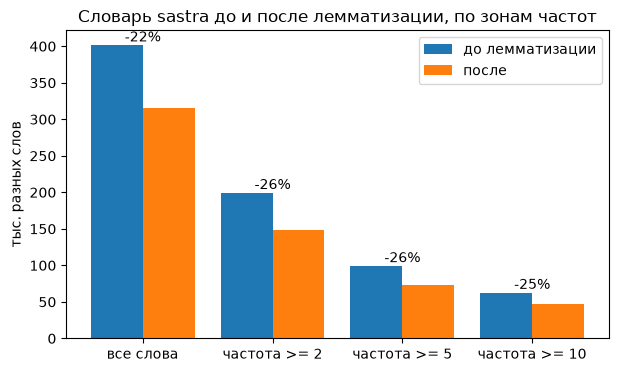

In [10]:
before_cnt, after_cnt = Counter(), Counter()
for ln in open(os.path.join(CLEAN, "corpus_segments_sastra.txt"),
               encoding="utf-8"):
    before_cnt.update(ln.split())
for ln in open(os.path.join(LEMMA, "corpus_segments_sastra.txt"),
               encoding="utf-8"):
    after_cnt.update(ln.split())

thresholds = [1, 2, 5, 10]
labels = ["все слова", "частота >= 2", "частота >= 5", "частота >= 10"]
b_vals = [sum(1 for c in before_cnt.values() if c >= t) / 1000
          for t in thresholds]
a_vals = [sum(1 for c in after_cnt.values() if c >= t) / 1000
          for t in thresholds]

x = range(len(labels))
plt.figure(figsize=(7, 4))
plt.bar([i - 0.2 for i in x], b_vals, width=0.4, label="до лемматизации")
plt.bar([i + 0.2 for i in x], a_vals, width=0.4, label="после")
for i in x:
    plt.text(i, max(b_vals[i], a_vals[i]) + 5,
             f"-{100 * (1 - a_vals[i] / b_vals[i]):.0f}%", ha="center")
plt.xticks(x, labels)
plt.ylabel("тыс. разных слов")
plt.title("Словарь sastra до и после лемматизации, по зонам частот")
plt.legend()
plt.show()

In [11]:
def _der_reduces_to(a, b):
    # достижимо ли b из a снятием ТОЛЬКО деривации (UD сводит глубже нас)?
    frontier, seen = [a], {a}
    for _ in range(3):
        nxt = []
        for w in frontier:
            for c in der_candidates(w):
                if c == b:
                    return True
                if c not in seen and len(c) >= 3:
                    seen.add(c)
                    nxt.append(c)
        frontier = nxt
        if not frontier:
            break
    return False

def evaluate(conllu_path):
    total = correct = chg = ok = part = wr = der_div = miss = 0
    for ln in open(conllu_path, encoding="utf-8"):
        cols = ln.split("\t")
        if len(cols) != 10 or not cols[0].isdigit():
            continue
        form, gold = cols[1].lower(), cols[2].lower()
        if not form.isalpha() or cols[3] in ("PUNCT", "SYM", "NUM", "PROPN"):
            continue
        f, g = normalize(form), normalize(gold)
        p = lem.lemma(f)
        total += 1
        correct += p == g
        if p != f:                              # сделали замену
            chg += 1
            if p == g:
                ok += 1
            elif _der_reduces_to(p, g):
                part += 1                       # сняли инфлексию, UD снял и деривацию
            else:
                wr += 1                         # реально иная замена
        elif g != f:                            # оставили, а UD поменял
            if _der_reduces_to(f, g):
                der_div += 1
            else:
                miss += 1
    print(f"токенов: {total}, точное совпадение с UD: {correct / total:.3f}")
    print(f"наши замены ({chg}): точно {100 * ok / chg:.0f}%, "
          f"частично (UD глубже, деривация) {100 * part / chg:.0f}%, "
          f"иначе {100 * wr / chg:.0f}%")
    print(f"  -> ложных замен от всех токенов: {100 * wr / total:.1f}%")
    print(f"оставили, а UD сменил: деривация {100 * der_div / total:.1f}% "
          f"(осознанно), недобор {100 * miss / total:.1f}% (нет корня)")

if os.path.exists("eval/jv_csui-ud-test.conllu"):
    evaluate("eval/jv_csui-ud-test.conllu")

токенов: 9968, точное совпадение с UD: 0.824
наши замены (1059): точно 54%, частично (UD глубже, деривация) 31%, иначе 15%
  -> ложных замен от всех токенов: 1.6%
оставили, а UD сменил: деривация 4.0% (осознанно), недобор 8.8% (нет корня)


 7634 (76.6%)  менять не надо: верно оставили
  576 ( 5.8%)  менять надо: тронули верно
  468 ( 4.7%)  менять надо: не разобрали (корня нет в лексиконе)
  408 ( 4.1%)  менять надо: сознательно оставили (служебное/словарное)
  399 ( 4.0%)  менять надо: осознанно оставили деривацию (UD глубже)
  324 ( 3.3%)  менять надо: тронули, UD свёл глубже (деривация)
   92 ( 0.9%)  менять не надо: ЗРЯ ТРОНУЛИ
   67 ( 0.7%)  менять надо: тронули иначе (расхождение)

из наших замен: точно верных 54%, хороших с частичными 85%


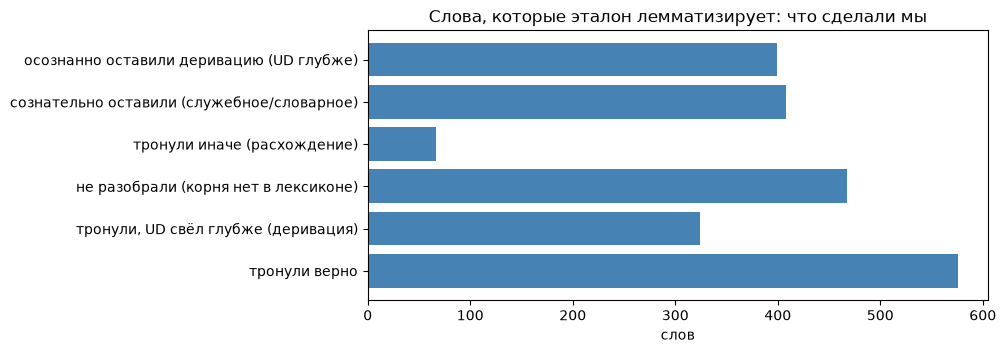

In [12]:
stat = Counter()
for ln in open("eval/jv_csui-ud-test.conllu", encoding="utf-8"):
    cols = ln.split("\t")
    if len(cols) != 10 or not cols[0].isdigit():
        continue
    form, gold = cols[1].lower(), cols[2].lower()
    if not form.isalpha() or cols[3] in ("PUNCT", "SYM", "NUM", "PROPN"):
        continue
    f, g = normalize(form), normalize(gold)
    p = lem.lemma(f)
    if g == f:
        stat["менять не надо: верно оставили" if p == f
             else "менять не надо: ЗРЯ ТРОНУЛИ"] += 1
    elif p == g:
        stat["менять надо: тронули верно"] += 1
    elif p != f:
        if _der_reduces_to(p, g):
            stat["менять надо: тронули, UD свёл глубже (деривация)"] += 1
        else:
            stat["менять надо: тронули иначе (расхождение)"] += 1
    elif _der_reduces_to(f, g):
        stat["менять надо: осознанно оставили деривацию (UD глубже)"] += 1
    elif f in lem.roots or (lem.freq.get(f, 0) >= 5000 and len(f) <= 7) \
            or len(f) < 4:
        stat["менять надо: сознательно оставили (служебное/словарное)"] += 1
    else:
        stat["менять надо: не разобрали (корня нет в лексиконе)"] += 1

total = sum(stat.values())
for k, v in stat.most_common():
    print(f"{v:>5} ({100 * v / total:4.1f}%)  {k}")

changed = sum(v for k, v in stat.items() if "тронули" in k or "ЗРЯ" in k)
good = (stat["менять надо: тронули верно"]
        + stat["менять надо: тронули, UD свёл глубже (деривация)"])
print(f"\nиз наших замен: точно верных "
      f"{100 * stat['менять надо: тронули верно'] / changed:.0f}%, "
      f"хороших с частичными {100 * good / changed:.0f}%")

labels = [k.split(": ")[1] for k in stat if k.startswith("менять надо")]
vals = [stat[k] for k in stat if k.startswith("менять надо")]
plt.figure(figsize=(8, 3.5))
plt.barh(labels, vals, color="steelblue")
plt.title("Слова, которые эталон лемматизирует: что сделали мы")
plt.xlabel("слов")
plt.show()

## 5. SVD (текстовый корпус, размерность <= 32)
TF-IDF (тексты x слова) -> scipy svds (random_state фиксирован) -> словарь слово->вектор.

In [13]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from scipy.sparse.linalg import svds

EMB = "embeddings"
os.makedirs(EMB, exist_ok=True)
JAV_TOKEN = r"[a-z][a-z0-9-]+"   # яванский алфавит + цифры + дефис

def make_matrix_W(corpus_path, min_df=5, token_pattern=JAV_TOKEN):
    """W: тексты x слова (TF-IDF), как в примере инструкции."""
    vec = TfidfVectorizer(analyzer="word", min_df=min_df,
                          token_pattern=token_pattern, use_idf=True)
    with open(corpus_path, encoding="utf-8") as f:
        W = vec.fit_transform(f)
    return W, vec.get_feature_names_out()

def apply_svd(W, k):
    """SVD ранга k; svds не гарантирует ни порядок, ни знак - сортируем по
    убыванию, random_state фиксируем для воспроизводимости."""
    u, sigma, vt = svds(W, k, random_state=0)
    order = np.flip(np.argsort(sigma))
    sigma, vt = sigma[order], vt[order]
    assert sigma.shape == (k,) and vt.shape == (k, W.shape[1])
    return np.dot(np.diag(sigma), vt).T, sigma     # (слова x k), sigma

K = 32   # размерность по заданию <= 32
W, words = make_matrix_W(os.path.join(LEMMA, "corpus_text_sastra.txt"))
vv, sigma = apply_svd(W, K)
svd_dict = {w: v for w, v in zip(words, vv)}
np.save(os.path.join(EMB, f"svd_sastra_{K}.npy"), svd_dict)

print(f"W (тексты x слова): {W.shape}, словарь: {len(words)}")
print(f"эмбеддинги: {vv.shape} -> {EMB}/svd_sastra_{K}.npy")
print("топ-8 сингулярных значений:", np.round(sigma[:8], 2))

W (тексты x слова): (2105, 60105), словарь: 60105
эмбеддинги: (60105, 32) -> embeddings/svd_sastra_32.npy
топ-8 сингулярных значений: [21.43  9.36  8.67  7.66  5.58  4.94  4.71  4.47]


In [14]:
# свойство SVD: вектор размерности m <= K - это первые m компонент
print("'ratu': K=32 ->", np.round(svd_dict["ratu"][:4], 3), "...")
print("'ratu': m=2  ->", np.round(svd_dict["ratu"][:2], 3), "(те же первые 2)")

# ближайшие соседи по косинусу
norm = vv / (np.linalg.norm(vv, axis=1, keepdims=True) + 1e-9)
widx = {w: i for i, w in enumerate(words)}

def neighbors(word, topn=8):
    if word not in widx:
        return f"'{word}' нет в словаре"
    sims = norm @ norm[widx[word]]
    return ", ".join(f"{words[j]}({sims[j]:.2f})"
                     for j in np.argsort(-sims)[1:topn + 1])

print("\nближайшие соседи (тематические кластеры):")
for q in ["ratu", "prabu", "perang", "banyu", "omah", "putri"]:
    print(f"  {q:>7}: {neighbors(q)}")

# регистровые пары держим разными леммами - но вектора должны быть близки
def cos(a, b):
    return float(norm[widx[a]] @ norm[widx[b]]) \
        if a in widx and b in widx else None

print("\nрегистровые пары (одно значение, разные леммы) - косинус:")
for a, b in [("ratu", "raja"), ("mangan", "dhahar"), ("banyu", "toya"),
             ("omah", "griya"), ("wong", "tiyang")]:
    v = cos(a, b)
    print(f"  cos({a}, {b}) = {v:.2f}" if v is not None else f"  {a}/{b}: n/a")

'ratu': K=32 -> [ 0.811  0.04   0.077 -0.182] ...
'ratu': m=2  -> [0.811 0.04 ] (те же первые 2)

ближайшие соседи (тематические кластеры):
     ratu: saleksa(0.92), patutan(0.88), ulubalang(0.87), eram(0.87), buja(0.86), leksa(0.86), anyakrawati(0.86), ngajani(0.86)
    prabu: sayembara(0.90), kadhaton(0.89), rajaputra(0.86), kabaranang(0.86), prameswari(0.86), andhustha(0.85), sakadang(0.85), dewi(0.85)
   perang: sasirep(0.89), nyenapateni(0.86), anulungi(0.81), panempuhing(0.81), sasedherek(0.79), paprangan(0.79), ketaton(0.79), ijen-ijenan(0.79)
    banyu: abang(0.92), rupa(0.91), ireng(0.91), susuh(0.90), aran(0.90), ijo(0.89), asin(0.88), kodhok(0.87)
     omah: dhisik(0.96), entek(0.96), cedhak(0.95), krungu(0.94), enom(0.94), tau(0.94), bengi(0.93), bojo(0.93)
    putri: kantaka(0.89), nelasah(0.89), aniyup(0.89), linungsir-lungsir(0.88), orem(0.87), retna(0.87), pamapag(0.86), ibu(0.86)

регистровые пары (одно значение, разные леммы) - косинус:
  cos(ratu, raja) = 0.85
  cos(

## 6. CBoW (сегментный корпус)
gensim Word2Vec sg=0, 100 мерностей. Соседи у CBoW - прямые синонимы.

In [15]:
from gensim.models import Word2Vec

CBOW_DIM = 100
with open(os.path.join(LEMMA, "corpus_segments_sastra.txt"), encoding="utf-8") as f:
    seg_sents = [ln.split() for ln in f if ln.strip()]

# sg=0 -> CBoW; workers=1 + seed=0 (+ запуск с PYTHONHASHSEED=0) для воспроизводимости
cbow = Word2Vec(sentences=seg_sents, vector_size=CBOW_DIM, window=5,
                min_count=5, sg=0, epochs=5, workers=1, seed=0)
cbow_dict = {w: cbow.wv[w] for w in cbow.wv.key_to_index}

def save_dictionary(fname, dictionary, dim):
    # формат примера-нутбука: первая строка "N dim", затем "слово v1 v2 ..."
    with open(fname, "w", encoding="utf-8") as f:
        f.write(f"{len(dictionary)} {dim}\n")
        for w, v in dictionary.items():
            f.write(w + " " + " ".join(map(str, v)) + "\n")

save_dictionary(os.path.join(EMB, f"cbow_sastra_{CBOW_DIM}.txt"), cbow_dict, CBOW_DIM)
cbow.wv.save(os.path.join(EMB, f"cbow_sastra_{CBOW_DIM}.kv"))
print(f"CBoW: предложений {len(seg_sents)}, словарь {len(cbow_dict)} слов, "
      f"размерность {CBOW_DIM}")
print(f"сохранено: {EMB}/cbow_sastra_{CBOW_DIM}.txt (+ .kv для быстрой загрузки)")

CBoW: предложений 2254719, словарь 73084 слов, размерность 100
сохранено: embeddings/cbow_sastra_100.txt (+ .kv для быстрой загрузки)


In [16]:
print("CBoW ближайшие соседи (синонимы/семантика):")
for q in ["ratu", "prabu", "perang", "banyu", "omah", "putri", "tresna"]:
    if q in cbow.wv:
        s = cbow.wv.most_similar(q, topn=8)
        print(f"  {q:>7}: " + ", ".join(f"{w}({c:.2f})" for w, c in s))

print("\nрегистровые пары (одно значение, разные леммы) - косинус:")
for a, b in [("ratu", "raja"), ("mangan", "dhahar"), ("banyu", "toya"),
             ("omah", "griya"), ("wong", "tiyang")]:
    if a in cbow.wv and b in cbow.wv:
        print(f"  cos({a}, {b}) = {cbow.wv.similarity(a, b):.2f}")

CBoW ближайшие соседи (синонимы/семантика):
     ratu: rathu(0.85), narpati(0.61), raja(0.58), ksatriya(0.58), senapati(0.54), nata(0.53), hapsari(0.52), nerpati(0.51)
    prabu: aprabu(0.73), rajaputra(0.67), thatha(0.67), widura(0.66), nata(0.66), duryudana(0.65), bisma(0.63), sidharta(0.62)
   perang: prang(0.82), yuda(0.71), ayuda(0.67), aprang(0.66), paprangan(0.64), peperangan(0.64), aperang(0.62), jurit(0.62)
    banyu: sagara(0.68), geni(0.67), segara(0.66), warih(0.66), buthek(0.66), getih(0.65), adhem(0.64), tawa(0.63)
     omah: panggonan(0.74), panggonane(0.72), lungguhan(0.70), pomahan(0.69), dikon(0.68), ngendi-endi(0.67), palindriya(0.67), mrono(0.66)
    putri: prameswari(0.72), retna(0.68), wanodya(0.66), dewi(0.66), rajaputri(0.65), garwa(0.63), kusuma(0.61), kakung(0.60)
   tresna: trisna(0.81), katresnan(0.74), sengit(0.74), welasan(0.73), gething(0.70), asih(0.70), sih(0.67), nalangsa(0.67)

регистровые пары (одно значение, разные леммы) - косинус:
  cos(ratu, raja

## 7. Проверка эмбеддингов
Слова по смысловым группам: тепловая карта косинусов, PCA в 2D, контроль (штили vs случайные) и спектр SVD.

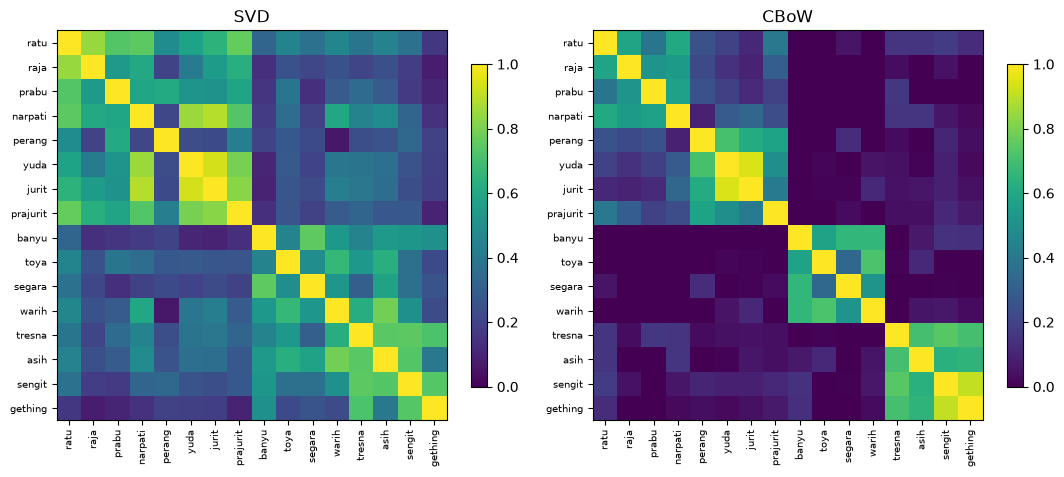

In [17]:
from sklearn.decomposition import PCA
E = {"SVD": svd_dict, "CBoW": cbow.wv}              # готовые словари из памяти
mat = lambda e, ws: np.array([e[w] for w in ws])
cos = lambda e, a, b: float(e[a] @ e[b] / (np.linalg.norm(e[a]) * np.linalg.norm(e[b])))
GROUPS = {"цари": ["ratu","raja","prabu","narpati"], "война": ["perang","yuda","jurit","prajurit"],
          "вода": ["banyu","toya","segara","warih"], "чувства": ["tresna","asih","sengit","gething"]}
ws = [w for gw in GROUPS.values() for w in gw]; grp = [g for g,gw in GROUPS.items() for _ in gw]
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
for k,(name,e) in enumerate(E.items()):            # тепловая карта косинусов: родственные = яркий блок
    A = mat(e, ws); A = A / np.linalg.norm(A, axis=1, keepdims=True)
    im = ax[k].imshow(A @ A.T, cmap="viridis", vmin=0, vmax=1)
    ax[k].set_xticks(range(len(ws)), ws, rotation=90, fontsize=7); ax[k].set_yticks(range(len(ws)), ws, fontsize=7)
    ax[k].set_title(name); fig.colorbar(im, ax=ax[k], shrink=.7)
plt.tight_layout(); plt.show()

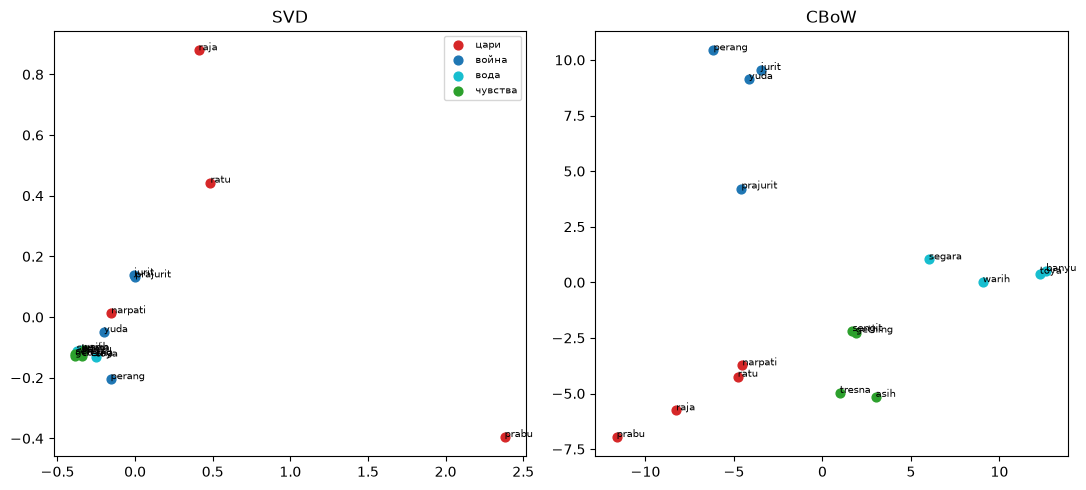

In [18]:
col = dict(zip(GROUPS, ["tab:red","tab:blue","tab:cyan","tab:green"]))
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
for k,(name,e) in enumerate(E.items()):            # PCA в 2D: группы расходятся в кластеры
    P = PCA(2).fit_transform(mat(e, ws))
    for g, c in col.items():
        idx = [i for i,gg in enumerate(grp) if gg == g]
        ax[k].scatter(*P[idx].T, c=c, label=g, s=40)
        for i in idx: ax[k].annotate(ws[i], P[i], fontsize=7)
    ax[k].set_title(name)
ax[0].legend(fontsize=7); plt.tight_layout(); plt.show()

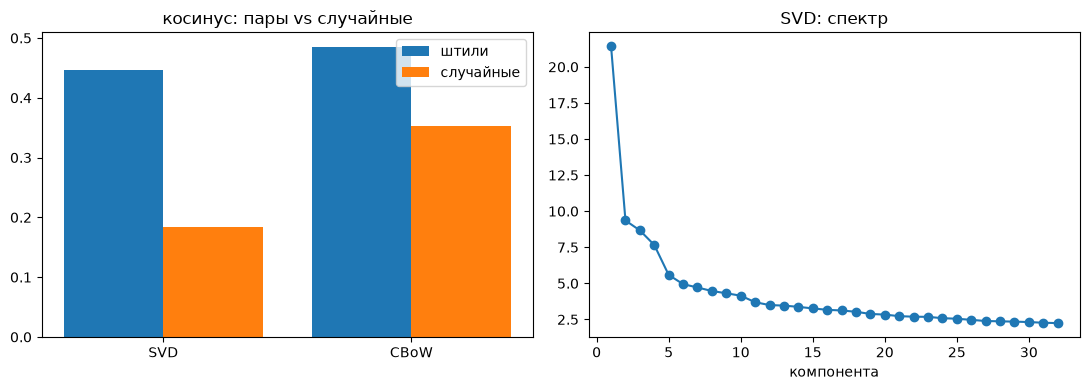

In [19]:
STYLE = [("ratu","raja"),("mangan","dhahar"),("banyu","toya"),("omah","griya"),("wong","tiyang"),("perang","yuda")]
rng = np.random.default_rng(0)
def rnd(e):                                        # ср. косинус случайных пар
    ks = list(getattr(e, "key_to_index", e))
    return np.mean([cos(e, ks[i], ks[j]) for i,j in rng.integers(0, len(ks), (300, 2))])
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
x = np.arange(len(E))                              # пары одного смысла должны быть ближе случайных
ax[0].bar(x-.2, [np.mean([cos(e,a,b) for a,b in STYLE]) for e in E.values()], .4, label="штили")
ax[0].bar(x+.2, [rnd(e) for e in E.values()], .4, label="случайные")
ax[0].set_xticks(x, list(E)); ax[0].legend(); ax[0].set_title("косинус: пары vs случайные")
sig = np.sort(np.linalg.norm(mat(svd_dict, list(svd_dict)), axis=0))[::-1]   # нормы столбцов = сингулярные значения
ax[1].plot(range(1, len(sig)+1), sig, "o-"); ax[1].set_title("SVD: спектр"); ax[1].set_xlabel("компонента")
plt.tight_layout(); plt.show()

## 8. Пространство эмбеддингов
Топ-2000 частых слов -> UMAP в 2D, цвет = KMeans-кластер. Видны регистры (ngoko/krama/кави), царская, природная, религиозная лексика.

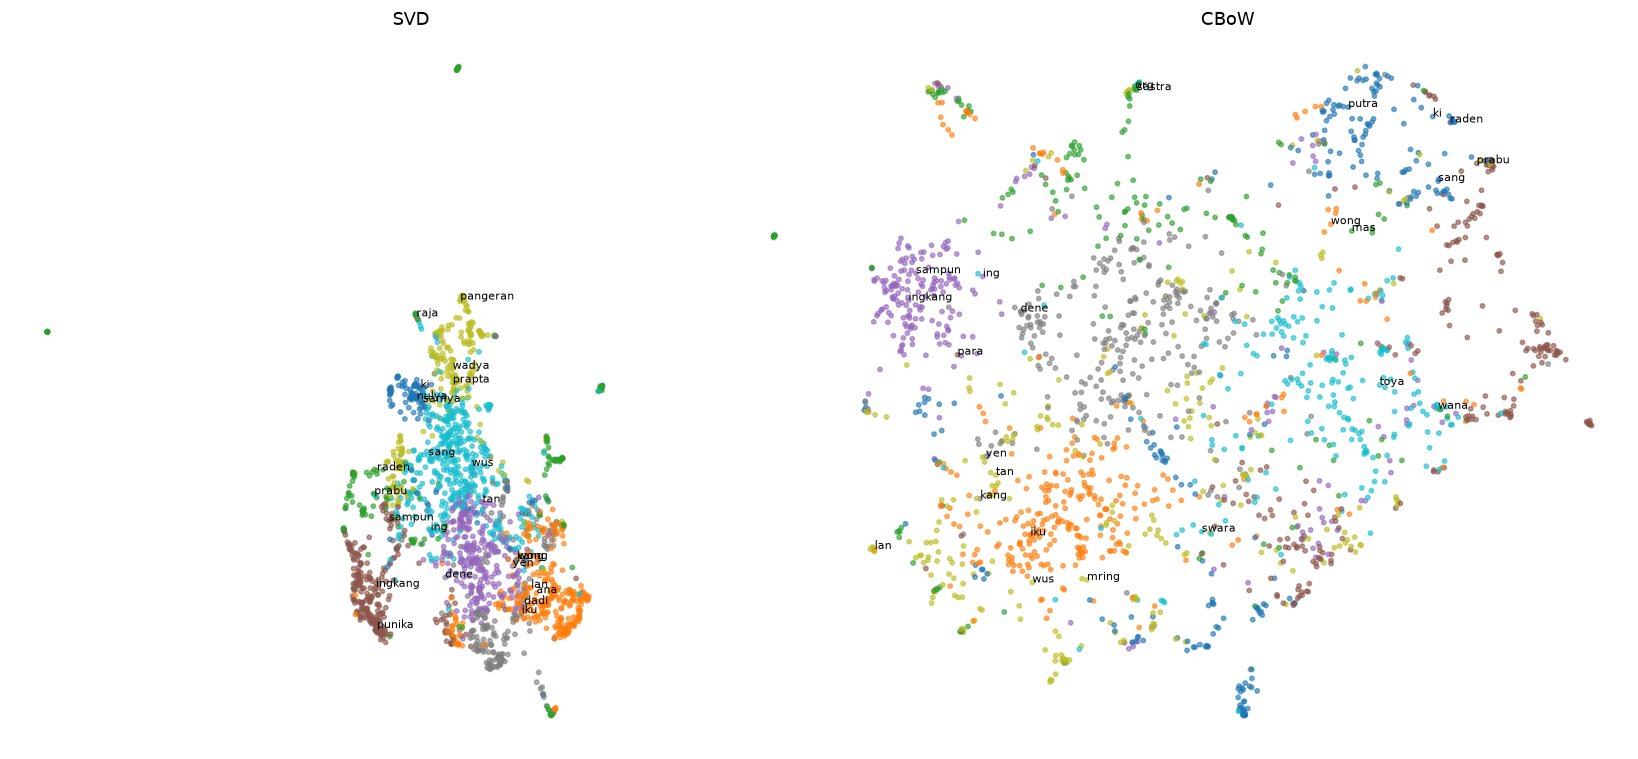

In [ ]:
from umap import UMAP
from sklearn.cluster import KMeans
W = [w for w in cbow.wv.index_to_key if w in svd_dict and w not in {"ordinal1","pron1"}][:2000]  # топ частых, в обоих
spaces = {"SVD": np.array([svd_dict[w] for w in W]), "CBoW": cbow.wv[W]}
fig, ax = plt.subplots(1, 2, figsize=(15, 7))
for k, (name, X) in enumerate(spaces.items()):
    X = X / np.linalg.norm(X, axis=1, keepdims=True)                 # косинусная геометрия
    cl = KMeans(8, random_state=0, n_init=10).fit_predict(X)         # автоматические кластеры
    P = UMAP(metric="cosine", random_state=0).fit_transform(X)       # 32/100 -> 2D
    ax[k].scatter(*P.T, c=cl, cmap="tab10", s=8, alpha=.6); ax[k].axis("off"); ax[k].set_title(name)
    for c in range(8):                                               # подписать топ-3 частых слова кластера
        for i in [j for j in range(len(W)) if cl[j] == c][:3]: ax[k].annotate(W[i], P[i], fontsize=7)
plt.tight_layout(); plt.show()